In [ ]:
##Assignment 06 :: Linear Regression

In [104]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
#importing dataset
from sklearn.datasets import load_breast_cancer

#assigning into smaller variable
br_c = load_breast_cancer()

x = br_c.data
y = br_c.target

df = pd.DataFrame(x, columns=br_c.feature_names)
df['target'] = y

# Display the first five rows
df.head(5)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [106]:
#findout the shape of the dataset
print("Dataset:", df.shape)

Dataset: (569, 31)


In [107]:
#Dataset Information
print("\n#Dataset Information:\n")
df.info()


#Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

In [108]:

#find  missing values
print("\n\n\n #Missing values:\n")
print(df.isnull().sum(), "\n\n")

#find duplicates
print("Duplicate values:", df.duplicated().sum(), "\n\n\n")

df.describe()




 #Missing values:

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64 


Duplicate values: 0 





,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


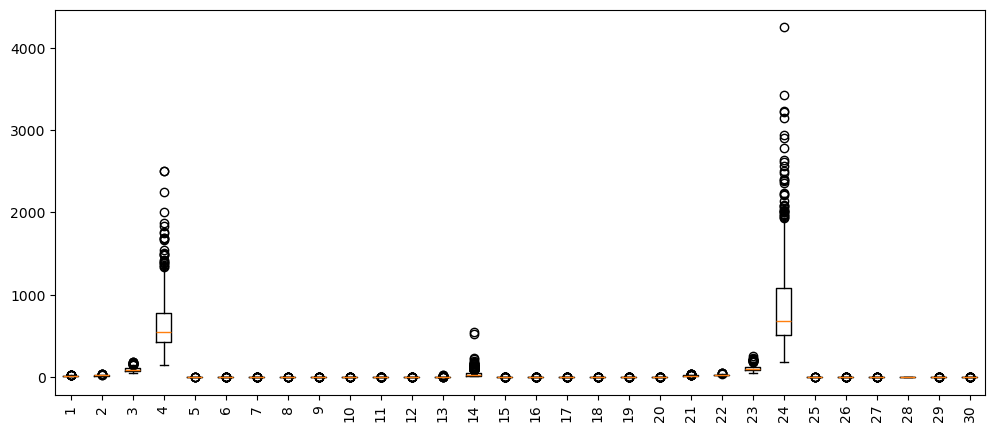

In [109]:
#check for outliers

plt.figure(figsize=(12,5))
plt.boxplot(x)
plt.xticks(rotation=90)
plt.show()

In [110]:
#Almost every group that exhibits variance also shows a strong positive (right) skew. 
#The outliers only extend upward, meaning the majority of data points sit at lower values 
#while a few rare instances spike dramatically higher.

In [111]:
#Performing Feature scaling

#we are using standard scaler
#importing the standard scale library
#importing train test split library
 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [112]:
#seperate features and target for better stability
x = df.drop("target",axis = 1)
y = df["target"]


In [113]:

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [114]:
#verify the train and test shape of the dataset

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [115]:
##Classification algorithm implementation

##Logistic Regression

#importing Library for Logistic Regression

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

#creating the logistic regression model

lr_model = LogisticRegression(random_state=42)

#Train the logistic regression model

lr_train = lr_model.fit(x_train, y_train)

#generate predictions from the trained data above

lr_pred = lr_train.predict(x_test)

#accuracy of the logistic regression
lr_acc = accuracy_score(y_test, lr_pred)
#incase of all, the model compares its predicted labels (lr_pred) against the true/targeted label (y_test).



In [116]:
##Decision Tree Classifier

#Importing decision tree classifier library

from sklearn.tree import DecisionTreeClassifier

#creating decision tree model

DT_model =  DecisionTreeClassifier(random_state=42)

#train the DT  model

DT_train = DT_model.fit(x_train, y_train)

#generate predictions from the ttrained DT above

DT_pred = DT_train.predict(x_test)

#accuracy of  DT

DT_acc = accuracy_score(y_test, DT_pred)
#process as above mentioned Lr model


In [117]:
##Random Forest Classifier

#Importing Random Forest Library

from sklearn.ensemble import RandomForestClassifier

#creating random forest classifier

rf_model = RandomForestClassifier(random_state=42)

#training the rf model

rf_train = rf_model.fit(x_train,y_train)

#generate predictions from trained rf above

rf_pred = rf_train.predict(x_test)

#accuracy of rf model

rf_acc = accuracy_score(y_test, rf_pred)
#process as above mentioned rf model


In [118]:
#support vector machine(SVM)

#imporrrting the library

from sklearn.svm import  SVC

#creating the model

svm_model = SVC()

#training the svm model

svm_train = svm_model.fit(x_train, y_train)

#generate predictions from the svm model

svm_pred = svm_train.predict(x_test)

#accuracy of the model

svm_acc = accuracy_score(y_test, svm_pred)
#process as above mentioned


In [119]:
# K-Nearest Neighbor(k-NN)

#importing the k-NN library
from sklearn.neighbors import KNeighborsClassifier

#creating the model

knn_model = KNeighborsClassifier()

#training the knn model

knn_train = knn_model.fit(x_train, y_train)

#geneerate predictions from the knn model

knn_pred = knn_train.predict(x_test)

# accuracy of knn model

knn_acc = accuracy_score(y_test, knn_pred )
#process as mentioned above


In [120]:
#print accuracy sheet
results = pd.DataFrame({
    "Algorithm" : [
   "Logistic model:",
   "Decision Tree:",
   "Random forest classifier:",
   "SVM model:", 
   "knn model:"
    ],
    "Accuracy" : [
        lr_acc,
        DT_acc,
        rf_acc,
        svm_acc,
        knn_acc
    ]
})

print(results)

                   Algorithm  Accuracy
0            Logistic model:  0.973684
1             Decision Tree:  0.947368
2  Random forest classifier:  0.964912
3                 SVM model:  0.973684
4                 knn model:  0.947368


In [121]:
#sorting the results

results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print(results)

                   Algorithm  Accuracy
0            Logistic model:  0.973684
1                 SVM model:  0.973684
2  Random forest classifier:  0.964912
3             Decision Tree:  0.947368
4                 knn model:  0.947368


In [122]:
#Setting up the classification report
print("-------------------------------------------------")
print("Logistic Regression")
print("-------------------------------------------------")

print(classification_report(y_test, lr_pred))

print("\n\n-------------------------------------------------")
print("Support Vector Machine")
print("-------------------------------------------------")
print(classification_report(y_test, svm_pred))

print("\n\n-------------------------------------------------")
print("Random Forest Classifier")
print("-------------------------------------------------")

print(classification_report(y_test, rf_pred))

print("\n\n-------------------------------------------------")
print("Decision Tree")
print("-------------------------------------------------")

print(classification_report(y_test, DT_pred))

print("\n\n-------------------------------------------------")
print("k-Nearest Neighbor ")
print("-------------------------------------------------")


print(classification_report(y_test, knn_pred))

-------------------------------------------------
Logistic Regression
-------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



-------------------------------------------------
Support Vector Machine
-------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



-------------------------------------------------
Random Forest Classifier
------------------------

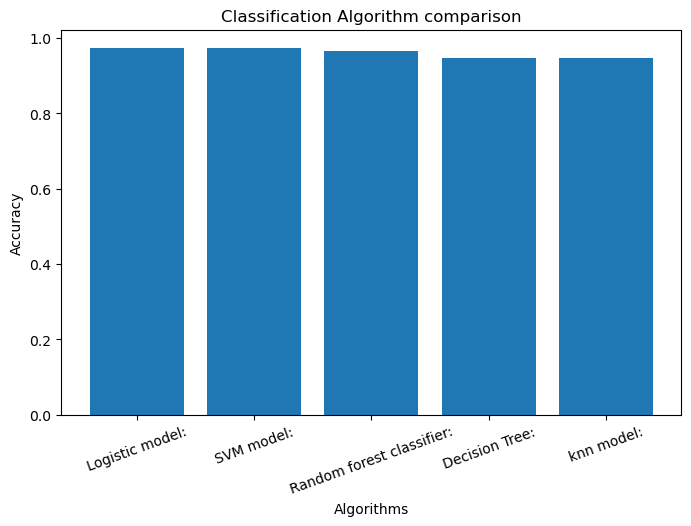

In [123]:
#Visualization of the comparisons

plt.figure(figsize=(8,5))

plt.bar(results["Algorithm"], results["Accuracy"])

plt.title("Classification Algorithm comparison")

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [129]:

'''Steps performed:


Loaded the data with load_breast_cancer() and converted it into a pandas DataFrame (features) and Series (target) for easier handling.

Checked for missing values — the dataset has zero missing values across all 30 features, so no imputation was required.

Train/test split — 80/20 split, using stratify=y so the malignant/benign class ratio (37% / 63%) is preserved in both sets.

Feature scaling with StandardScaler (zero mean, unit variance), fit on the training set only and applied to both train and test sets.'

Implemented and analysed five classification algorithms in the dataset.

Evaluated on the held-out 20% test set (114 samples)

------------------------------------------------------------------------------------------------------------------------------------------------

#Best performing: Logistic Regression and SVM (RBF), tied at 97.36% accuracy. Both benefit from the dataset's fairly clean, well-scaled, 
 and largely linearly/smoothly separable structure — Logistic Regression fits a strong linear boundary, and the RBF-kernel SVM finds a 
 maximum-margin boundary that generalizes very well on this feature set.

#Worst performing: kNN and Decision Tree, at than than 94.73% accuracy. A single decision tree tends to overfit the training data and is  
 less stable than other methods — small changes in the training data can shift its splits, which shows up as noticeably lower recall on 
 the malignant class here (0.93 vs. 0.98+ for the top models).'''

"Steps performed:\n\n\nLoaded the data with load_breast_cancer() and converted it into a pandas DataFrame (features) and Series (target) for easier handling.\n\nChecked for missing values — the dataset has zero missing values across all 30 features, so no imputation was required.\n\nTrain/test split — 80/20 split, using stratify=y so the malignant/benign class ratio (37% / 63%) is preserved in both sets.\n\nFeature scaling with StandardScaler (zero mean, unit variance), fit on the training set only and applied to both train and test sets.'\n\nImplemented and analysed five classification algorithms in the dataset.\n\nEvaluated on the held-out 20% test set (114 samples)\n\n------------------------------------------------------------------------------------------------------------------------------------------------\n\n#Best performing: Logistic Regression and SVM (RBF), tied at 97.36% accuracy. Both benefit from the dataset's fairly clean, well-scaled, \n and largely linearly/smoothly se